In [59]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

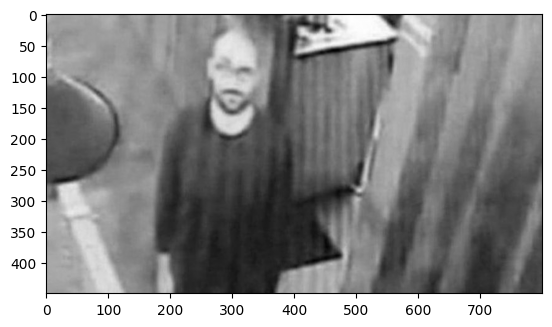

In [60]:
cctv = cv.imread("backup.jpg", cv.IMREAD_GRAYSCALE)
plt.imshow(cctv, cmap='gray')

In [61]:
def convolution(img, kernel):
    # Ukuran kernel
    size = kernel.shape[0]
    
    # Ukuran padding
    pad_size = size // 2
    
    # Tambah padding nol (constant)
    padded = np.pad(img, pad_size, mode='constant')
    
    # Kanvas hasil (gunakan float32 untuk menampung nilai negatif/desimal)
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    
    for i in range(height):
        for j in range(width):
            # Area kernel
            region = padded[i:i+size, j:j+size]
            # Hitung konvolusi: jumlah dari perkalian region dengan kernel
            canvas[i, j] = np.sum(region * kernel)
            
    return canvas

In [62]:
# --- Kernel Perbaikan Citra ---
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

# --- Kernel Sobel ---
sobelx = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobely = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

# --- Kernel Prewitt ---
prewittx = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewitty = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)

# --- Kernel Roberts ---
robertsx = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

robertsy = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)

In [63]:
def edge_detection(img, kernelx, kernely):
    # Konvolusi sumbu x dan y
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    
    # Gabung gradien absolut agar tidak ada nilai negatif
    canvas = np.abs(gx) + np.abs(gy)
    
    # Normalisasi ke rentang 0-255
    if np.max(canvas) != 0:
        canvas = (canvas * 255.0) / np.max(canvas)
    
    # Batas nilai (clip) dan konversi ke uint8
    return np.clip(canvas, 0, 255).astype(np.uint8)

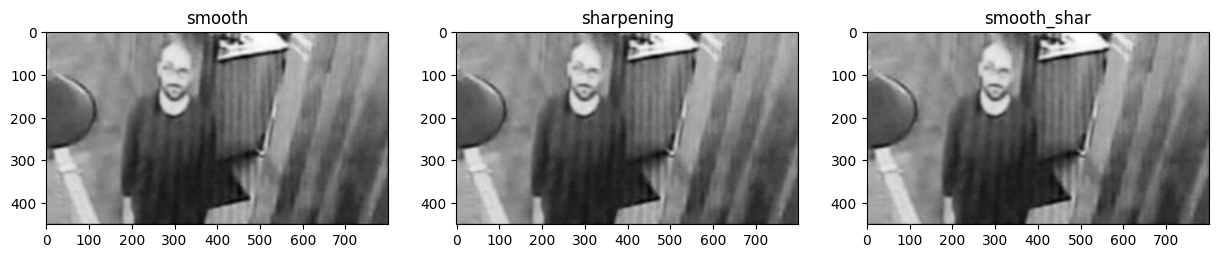

In [64]:
cctv_smooth = convolution(cctv, kernelSmoothing)
cctv_sharpening = convolution(cctv, kernelSharpening)
cctv_smooth_shar = cctv_smooth + cctv_sharpening

plt.figure(figsize=(15, 10))

plt.subplot(1, 3, 1)
plt.title('smooth')
plt.imshow(cctv_smooth, cmap='gray')
plt.subplot(1, 3, 2)
plt.title('sharpening')
plt.imshow(cctv_sharpening, cmap='gray')
plt.subplot(1, 3, 3)
plt.title('smooth_shar')
plt.imshow(cctv_smooth_shar , cmap='gray')

In [65]:
def edge_detection(img, kernelx, kernely):
    # Konvolusi sumbu x dan y
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    
    # Gabung gradien absolut agar tidak ada nilai negatif
    canvas = np.abs(gx) + np.abs(gy)
    
    # Normalisasi ke rentang 0-255
    if np.max(canvas) != 0:
        canvas = (canvas * 255.0) / np.max(canvas)
    
    # Batas nilai (clip) dan konversi ke uint8
    return np.clip(canvas, 0, 255).astype(np.uint8)

In [66]:
prewitt1 = edge_detection(cctv_smooth_shar, prewittx, prewitty)
sobel = edge_detection(cctv_smooth_shar, sobelx, sobely)
roberts = edge_detection(cctv_smooth_shar, robertsx, robertsy)

Text(0.5, 1.0, 'prewitt_sobel_roberts')

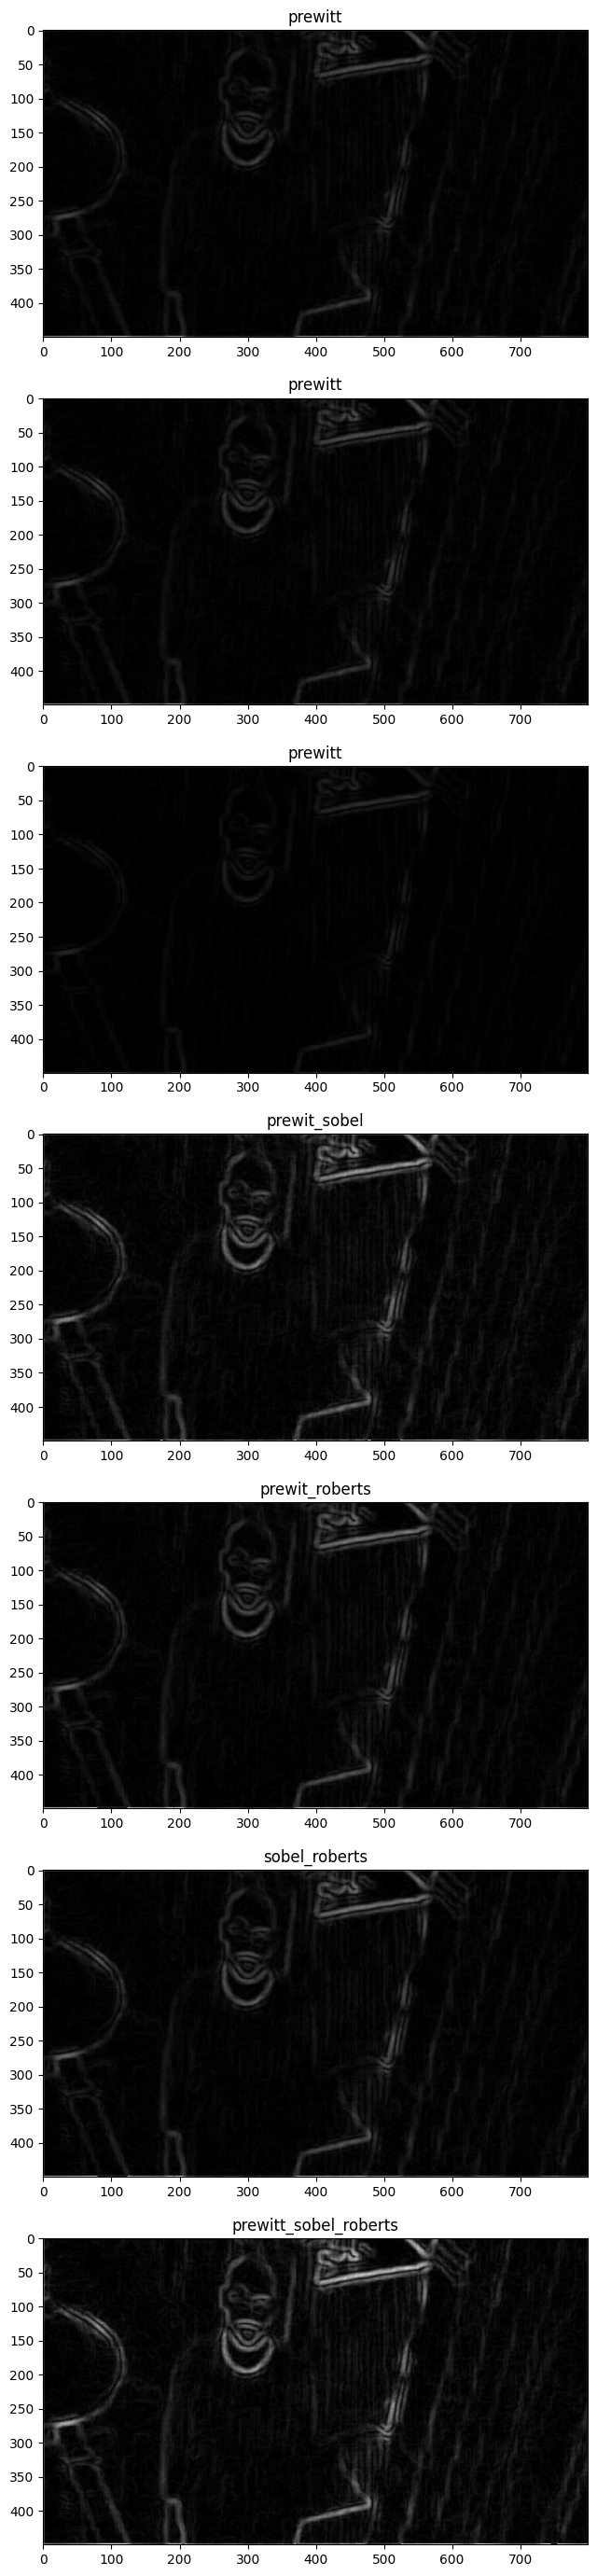

In [67]:
plt.figure(figsize=(15, 35))

plt.subplot(7, 1, 1)
plt.imshow(prewitt1, cmap="gray")
plt.title("prewitt")
plt.subplot(7, 1, 2)
plt.imshow(sobel, cmap="gray")
plt.title("prewitt")
plt.subplot(7, 1, 3)
plt.imshow(roberts, cmap="gray")
plt.title("prewitt")

prewit_sobel = prewitt1 + sobel
plt.subplot(7, 1, 4)
plt.imshow(prewit_sobel, cmap="gray")
plt.title("prewit_sobel")

prewit_roberts = prewitt1 + roberts
plt.subplot(7, 1, 5)
plt.imshow(prewit_roberts, cmap="gray")
plt.title("prewit_roberts")

sobel_roberts = sobel + roberts
plt.subplot(7, 1, 6)
plt.imshow(sobel_roberts, cmap="gray")
plt.title("sobel_roberts")

prewitt_sobel_roberts = prewitt1 + sobel + roberts
plt.subplot(7, 1, 7)
plt.imshow(prewitt_sobel_roberts, cmap="gray")
plt.title("prewitt_sobel_roberts")

In [68]:
def tresholding(img, treshold):
    h, w = img.shape 
    rot = np.zeros((h, w), dtype=img.dtype)
    for i in range(h): 
        for j in range(w): 
            if( img[i, j] > treshold):
                rot[i, j] = 255
            else :
                rot[i, j] = 0
    return rot

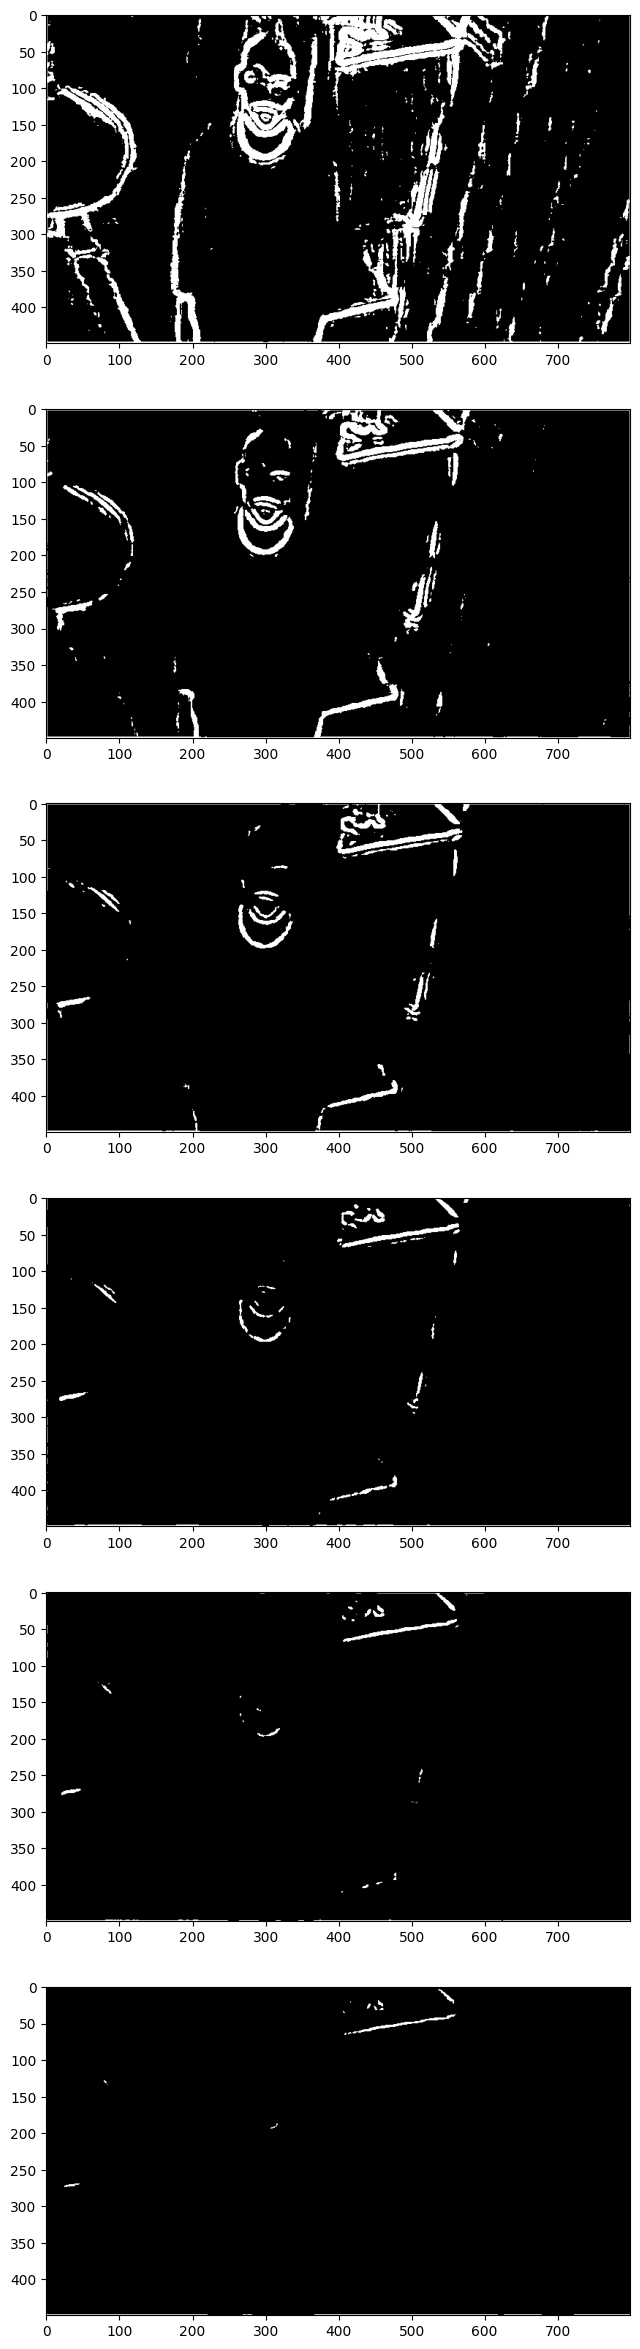

In [69]:
treshold10 = tresholding(prewitt1, 10)
treshold20 = tresholding(prewitt1, 20)
treshold30 = tresholding(prewitt1, 30)
treshold40 = tresholding(prewitt1, 40)
treshold50 = tresholding(prewitt1, 50)
treshold60 = tresholding(prewitt1, 60)

plt.figure(figsize=(15, 35))
plt.subplot(7, 1, 1)
plt.imshow(treshold10, cmap='gray')
plt.subplot(7, 1, 2)
plt.imshow(treshold20, cmap='gray')
plt.subplot(7, 1, 3)
plt.imshow(treshold30, cmap='gray')
plt.subplot(7, 1, 4)
plt.imshow(treshold40, cmap='gray')
plt.subplot(7, 1, 5)
plt.imshow(treshold50, cmap='gray')
plt.subplot(7, 1, 6)
plt.imshow(treshold60, cmap='gray')

In [70]:
def filter_citra(img, size, mode):
    # dimensi gambar / image dimensions
    height, width = img.shape
    # ukuran padding / padding size
    pad = size // 2
    # tambah padding tepi / add edge padding
    padded = np.pad(img, pad, mode='edge')
    # kanvas hasil / output canvas
    canvas = np.zeros_like(img, dtype=np.uint8)
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total_sum = 0
                    for row in region:
                        for pixel in row:
                            total_sum += int(pixel)
                    
                    canvas[i, j] = total_sum // area

        case 'median':
            # filter median / median filter
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # rumus median manual / manual median formula
                    values = []
                    for row in region:
                        for val in row:
                            values.append(val)
                    # urutkan manual / manual sort (bubble sort)
                    n = len(values)
                    for a in range(n):
                        for b in range(0, n - a - 1):
                            if values[b] > values[b + 1]:
                                values[b], values[b + 1] = values[b + 1], values[b]
                    # ambil nilai tengah / get middle value
                    mid = n // 2
                    if n % 2 == 0:
                        canvas[i, j] = (values[mid - 1] + values[mid]) // 2
                    else:
                        canvas[i, j] = values[mid]

        case 'modus':
            # filter modus / mode filter
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # ratakan array / flatten array
                    values = region.ravel()
                    # hitung kemunculan / count occurrences
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    # cari nilai terbanyak / find mode value
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    # simpan hasil / save result
                    canvas[i, j] = mode_val
    # kembalikan gambar / return image
    return canvas

# cara panggil / how to call
# hasil = filter_citra(foto_karim, 3, 'mean')

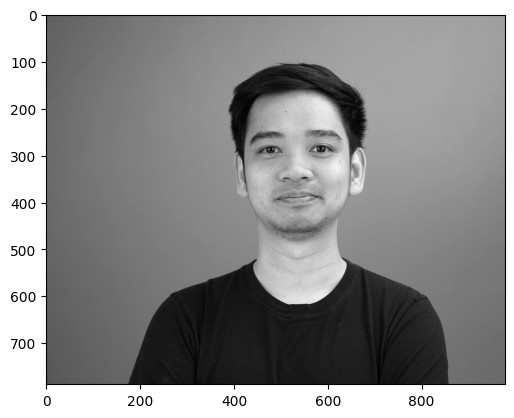

In [75]:
david = cv.imread("david.jpg")
david = cv.cvtColor(david, cv.COLOR_BGR2GRAY)
plt.imshow(david, cmap='gray')

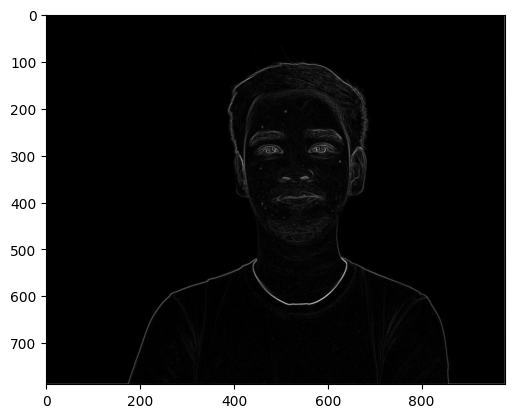

In [83]:
david_edge = edge_detection(david, prewittx, prewitty)

plt.imshow(david, cmap='gray')